<a href="https://colab.research.google.com/github/sulthanalihsan/data-science-2026/blob/main/Pertemuan12_Muhamad_Sulthan_Al_Ihsan_250401020154.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PERTEMUAN 12 : Asosiasi Data & Sistem Rekomendasi Dasar
**Nama  :** Muhammad Sulthan Al Ihsan

**NIM   :** 250401020154

**Mata Kuliah:** Data Science —  S1 PJJ Informatika

**Kelas:** IF401

    support       itemsets
0  0.666667         (Roti)
2  0.666667         (Susu)
3  0.500000        (Telur)
1  0.333333        (Selai)
4  0.333333  (Roti, Selai)
  antecedents consequents   support  confidence  lift
0      (Roti)     (Selai)  0.333333         0.5   1.5
1     (Selai)      (Roti)  0.333333         1.0   1.5


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


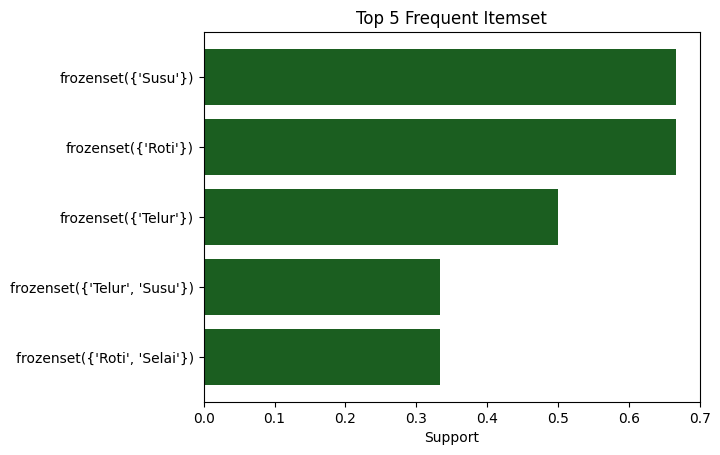

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
# ── 1. Contoh Data Transaksi ─────────────────
transaksi = [
['Roti', 'Susu', 'Telur'], ['Roti', 'Selai'],
['Susu', 'Telur', 'Keju'], ['Roti', 'Susu', 'Selai'],
['Roti', 'Telur'], ['Susu', 'Sereal'],
]
# ── 2. One-Hot Encoding ──────────────────────
te = TransactionEncoder()
te_ary = te.fit(transaksi).transform(transaksi)
df = pd.DataFrame(te_ary, columns=te.columns_)
# ── 3. Cari Frequent Itemset ───────────────
freq_items = apriori(df, min_support=0.3, use_colnames=True)
freq_items = freq_items.sort_values('support', ascending=False)
print(freq_items.head())
# ── 4. Bentuk & Saring Aturan Asosiasi ─────────
rules = association_rules(freq_items, metric='confidence',
min_threshold=0.5)
rules = rules[rules['lift'] > 1].sort_values('lift', ascending=False)
print(rules[['antecedents', 'consequents',
'support', 'confidence', 'lift']].head())
# ── 5. Visualisasi Top Itemset ─────────────
top = freq_items.sort_values('support').tail(5)
plt.barh(top['itemsets'].astype(str), top['support'], color='#1B5E20')
plt.xlabel('Support'); plt.title('Top 5 Frequent Itemset')
plt.show()

# Langkah 1: Generate & Eksplorasi Dataset Transaksi

In [2]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
produk = ['Roti', 'Selai', 'Susu', 'Sereal', 'Telur',
'Keju', 'Kopi', 'Gula', 'Teh', 'Mentega']
# Buat 50 transaksi, tiap transaksi berisi 2-5 produk
transaksi = []
for _ in range(50):
  n_item = np.random.randint(2, 6)
  transaksi.append(list(np.random.choice(produk, n_item, replace=False)))
# Suntikkan pola: Roti sering bersama Selai
for i in range(0, 20):
  if 'Roti' in transaksi[i] and 'Selai' not in transaksi[i]:
    transaksi[i].append('Selai')
print('Contoh transaksi:', transaksi[:3])
print('Jumlah transaksi:', len(transaksi))

Contoh transaksi: [[np.str_('Keju'), np.str_('Roti'), np.str_('Mentega'), np.str_('Kopi'), 'Selai'], [np.str_('Roti'), np.str_('Kopi'), np.str_('Teh'), np.str_('Selai'), np.str_('Mentega')], [np.str_('Kopi'), np.str_('Susu'), np.str_('Teh')]]
Jumlah transaksi: 50


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

# Langkah 2: One-Hot Encoding Transaksi
Ubah daftar transaksi menjadi tabel one-hot encoding menggunakan TransactionEncoder.

In [3]:
from mlxtend.preprocessing import TransactionEncoder
te = TransactionEncoder()
te_ary = te.fit(transaksi).transform(transaksi)
df = pd.DataFrame(te_ary, columns=te.columns_)
print(df.head())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

    Gula   Keju   Kopi  Mentega   Roti  Selai  Sereal   Susu    Teh  Telur
0  False   True   True     True   True   True   False  False  False  False
1  False  False   True     True   True   True   False  False   True  False
2  False  False   True    False  False  False   False   True   True  False
3  False   True  False    False  False   True   False  False   True   True
4   True   True  False     True  False  False   False   True  False  False


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

# Langkah 3: Cari Frequent Itemset dengan Apriori
Jalankan Apriori dengan beberapa nilai min_support, amati bagaimana jumlah itemset yang
ditemukan berubah.

In [5]:
from mlxtend.frequent_patterns import apriori
for ms in [0.05, 0.1, 0.2]:
  freq = apriori(df, min_support=ms, use_colnames=True)
print(f'min_support={ms}: {len(freq)} itemset ditemukan')
# Gunakan min_support yang menghasilkan jumlah itemset wajar (tidak 0, tidak ratusan)
freq_items = apriori(df, min_support=0.1, use_colnames=True)
freq_items = freq_items.sort_values('support', ascending=False)
print(freq_items.head(10))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

min_support=0.2: 13 itemset ditemukan
    support      itemsets
5      0.52       (Selai)
8      0.46         (Teh)
3      0.42     (Mentega)
9      0.36       (Telur)
1      0.34        (Keju)
0      0.32        (Gula)
2      0.32        (Kopi)
4      0.32        (Roti)
7      0.32        (Susu)
36     0.24  (Selai, Teh)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Catatan : Cell kode ini bertujuan mencari kombinasi produk yg paling sering muncul dlm transaksi. Pertama, dilakukan uji coba dgn bbrp nilai min_support (ambang batas minimum) untk melihat bagaimana parameter ini memengaruhi jml itemset yg terdeteksi. Langkah ini penting utk menemukan keseimbangan hasil agar tdk terlalu sedikit atau terlalu bnyk.

Stlh pengujian, nilai min_support 0.1 dipilih krn menghasilkan daftar kelompok produk yg dianggap ideal. Hasil output menunjukkan bahwa 'Selai' menempati urutan teratas dgn nilai support 0.52, yg berarti muncul dlm 52% dari total data. Selain itu, terlihat pula pola kombinasi sprt 'Selai' dn 'Teh' yg memiliki frekuensi kemunculan cukup signifikan bagi analisis asosiasi selanjutnya.